### Imports

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model, metrics
import numpy as np

2025-08-04 19:49:07.634435: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-04 19:49:07.712497: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754347747.741680    9705 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754347747.750041    9705 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754347747.813895    9705 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
gpus = tf.config.list_physical_devices('GPU')
print("GPU Available:", gpus)
print("cuDNN Enabled:", tf.test.is_built_with_cuda())

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Set the number of intra-op and inter-op threads
NUM_CORES = 8
tf.config.threading.set_intra_op_parallelism_threads(NUM_CORES)
tf.config.threading.set_inter_op_parallelism_threads(NUM_CORES)

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
cuDNN Enabled: True


### Definitions

In [6]:
# --- Constants ---
INPUT_SHAPE = 200
LATENT_DIM = 8
N_CENTROIDS = 6
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 1e-5
VALIDATION_SPLIT = 0.2 # Using 20% of data for validation

### Get train data

In [7]:
import tensorflow as tf
import os
from sklearn.model_selection import train_test_split
import math

# --- 1. Define Constants and Paths ---
# Please ensure these paths are correct for your setup
UNLABELED_IMAGES_PATH = "/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/dividing_rf"
LABELED_IMAGES_PATH = '/home/nicolas/Documentos/UTN/INA/giar_ina_dev/media/cropped_images/classification1/test'


# --- 2. Define Helper Functions (from your code) ---
def load_and_preprocess_image_tf(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    # The image is resized to a fixed shape here
    image = tf.image.resize(image, [INPUT_SHAPE, INPUT_SHAPE])
    image = tf.cast(image, tf.float32) / 255.0
    return image

def make_unlabeled_dataset(file_list, batch_size):
    """Creates a dataset for unlabeled images."""
    ds = tf.data.Dataset.from_tensor_slices(file_list)
    ds = ds.map(load_and_preprocess_image_tf, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

def make_labeled_dataset_keras(parent_folder, batch_size, input_shape):
    """Creates a labeled dataset from a directory structure using a Keras utility."""
    ds = tf.keras.utils.image_dataset_from_directory(
        directory=parent_folder,
        labels='inferred',
        label_mode='categorical',
        image_size=(input_shape, input_shape),
        color_mode='grayscale',
        # Set batch_size=None here to load all data for splitting first
        batch_size=None, 
        shuffle=True,
        seed=42
    )
    # Normalize images from [0, 255] to [0, 1]
    def normalize_img(image, label):
        return (image / 255.0, label)
    ds = ds.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
    return ds

# --- 3. Prepare UNLABELED Datasets ---
print("Preparing unlabeled data...")
unlabeled_files = [os.path.join(UNLABELED_IMAGES_PATH, image) for image in os.listdir(UNLABELED_IMAGES_PATH)]
unlabeled_train_files, unlabeled_test_files = train_test_split(unlabeled_files, test_size=VALIDATION_SPLIT, random_state=42)

unlabeled_train_ds = make_unlabeled_dataset(unlabeled_train_files, BATCH_SIZE)
unlabeled_test_ds = make_unlabeled_dataset(unlabeled_test_files, BATCH_SIZE)
print(f"Unlabeled data: {len(unlabeled_train_files)} train, {len(unlabeled_test_files)} test images.")


# --- 4. Prepare LABELED Datasets (with train/test split) ---
print("\nPreparing labeled data...")
# First, load the full labeled dataset without batching
full_labeled_ds = make_labeled_dataset_keras(LABELED_IMAGES_PATH, None, INPUT_SHAPE)

# Get the total size of the labeled dataset to calculate the split
labeled_dataset_size = tf.data.experimental.cardinality(full_labeled_ds).numpy()
test_size = int(VALIDATION_SPLIT * labeled_dataset_size)
train_size = labeled_dataset_size - test_size

# Split the dataset using .take() and .skip()
labeled_test_ds = full_labeled_ds.take(test_size)
labeled_train_ds = full_labeled_ds.skip(test_size)
print(f"Labeled data: {train_size} train, {test_size} test images.")

# Now, batch the split datasets
labeled_train_ds = labeled_train_ds.batch(BATCH_SIZE)
labeled_test_ds = labeled_test_ds.batch(BATCH_SIZE)


# --- 5. Combine Datasets for Training and Validation ---
print("\nZipping datasets for training and validation...")
# Use .repeat() on the smaller dataset (likely the labeled one) to ensure
# we can iterate through the entire larger (unlabeled) dataset.
train_dataset = tf.data.Dataset.zip((unlabeled_train_ds, labeled_train_ds.repeat()))
validation_dataset = tf.data.Dataset.zip((unlabeled_test_ds, labeled_test_ds.repeat()))

print("\n✅ Datasets are ready for semi-supervised training.")

Preparing unlabeled data...
Unlabeled data: 2402 train, 601 test images.

Preparing labeled data...
Found 2849 files belonging to 6 classes.
Labeled data: 2280 train, 569 test images.

Zipping datasets for training and validation...

✅ Datasets are ready for semi-supervised training.


### Helper functions

In [8]:
def gumbel_softmax(logits, temperature=1.0, hard=False):
    """
    Differentiable sampling from a categorical distribution using Gumbel-Softmax.
    
    Args:
        logits: [batch_size, n_categories] unnormalized log-probabilities.
        temperature: Float > 0. Controls the smoothness of the approximation.
        hard: If True, the output is one-hot.
    
    Returns:
        A soft or hard sample from the categorical distribution.
    """
    # Sample from Gumbel(0, 1)
    gumbel_noise = -tf.math.log(-tf.math.log(tf.random.uniform(tf.shape(logits), 0, 1)))
    
    # Apply noise and temperature
    y_soft = tf.nn.softmax((logits + gumbel_noise) / temperature)
    
    if hard:
        # Straight-through estimator
        k = tf.shape(logits)[-1]
        y_hard = tf.one_hot(tf.argmax(y_soft, axis=-1), depth=k)
        # Combine hard output with soft gradient
        y = tf.stop_gradient(y_hard - y_soft) + y_soft
        return y
    else:
        return y_soft

### Definition of the model

In [13]:
class MFCVAE(Model):
    def __init__(self, input_shape, latent_dim, n_centroids, temperature=0.5, name="mfc_vae", **kwargs):
        super(MFCVAE, self).__init__(name=name, **kwargs)
        self.input_shape_tuple = (input_shape, input_shape, 1)
        self.latent_dim = latent_dim
        self.n_centroids = n_centroids # This is 'K', the number of clusters
        self.temperature = temperature

        # ENCODER NETWORK q(z, c | x)
        # This network outputs the parameters for the latent distributions
        # and the categorical distribution over clusters.
        self.encoder = tf.keras.Sequential(
            [
                layers.InputLayer(shape=self.input_shape_tuple),
                layers.Conv2D(filters=32, kernel_size=5, strides=2, activation=tf.nn.leaky_relu, padding='same'),
                layers.BatchNormalization(),
                layers.Conv2D(filters=64, kernel_size=3, strides=2, activation=tf.nn.leaky_relu, padding='same'),
                layers.BatchNormalization(),
                layers.Conv2D(filters=128, kernel_size=3, strides=2, activation=tf.nn.leaky_relu, padding='same'),
                layers.BatchNormalization(),
                layers.Conv2D(filters=256, kernel_size=3, strides=2, activation=tf.nn.leaky_relu, padding='same'),
                layers.BatchNormalization(),
                layers.Conv2D(filters=512, kernel_size=3, strides=2, padding='same', activation=tf.nn.leaky_relu),
                layers.BatchNormalization(),
                layers.Flatten(),
                layers.Dense(1024, activation=tf.nn.leaky_relu),
            ], name="encoder"
        )
        
        # Output layer for Gaussian parameters (K * latent_dim * 2 for mu and log_var for each cluster)
        self.fc_mu = layers.Dense(n_centroids * latent_dim)
        self.fc_log_var = layers.Dense(n_centroids * latent_dim)
        
        # Output layer for categorical distribution parameters (logits for K clusters)
        self.fc_pi = layers.Dense(n_centroids)

        # DECODER NETWORK p(x | z): Upsamples 25x25 -> 50x50 -> 100x100 -> 200x200
        # This network reconstructs the input from a latent sample.
        decoder_start_spatial_dim = 7
        decoder_start_filters = 512
        self.decoder = tf.keras.Sequential(
            [
                layers.InputLayer(shape=(latent_dim,)),
                layers.Dense(units=decoder_start_spatial_dim * decoder_start_spatial_dim * decoder_start_filters, activation=tf.nn.leaky_relu),
                layers.BatchNormalization(),
                layers.Reshape(target_shape=(decoder_start_spatial_dim, decoder_start_spatial_dim, decoder_start_filters)),
                layers.Conv2DTranspose(filters=256, kernel_size=3, strides=2, padding='same', activation=tf.nn.leaky_relu),
                layers.BatchNormalization(),
                layers.Conv2DTranspose(filters=128, kernel_size=3, strides=2, padding='same', activation=tf.nn.leaky_relu),
                layers.BatchNormalization(),
                layers.Conv2DTranspose(filters=64, kernel_size=3, strides=2, padding='same', activation=tf.nn.leaky_relu),
                layers.BatchNormalization(),
                layers.Conv2DTranspose(filters=32, kernel_size=3, strides=2, padding='same', activation=tf.nn.leaky_relu),
                layers.BatchNormalization(),
                layers.Conv2DTranspose(filters=16, kernel_size=3, strides=2, padding='same', activation=tf.nn.leaky_relu),
                layers.BatchNormalization(),
                layers.Conv2DTranspose(filters=1, kernel_size=3, strides=1, padding='same', activation='sigmoid'),
                # The Cropping2D layer is a valid way to handle non-power-of-two dimensions
                # to get the exact output shape (e.g., 224x224 -> 200x200)
                layers.Cropping2D(((12, 12), (12, 12))),
            ], name="decoder"
        )

    def call(self, inputs):
        # Forward pass through the encoder
        x_encoded = self.encoder(inputs)
        
        # Get parameters for all K clusters
        # Reshape to [batch_size, n_centroids, latent_dim]
        all_mu = tf.reshape(self.fc_mu(x_encoded), [-1, self.n_centroids, self.latent_dim])
        all_log_var = tf.reshape(self.fc_log_var(x_encoded), [-1, self.n_centroids, self.latent_dim])
        
        # Get parameters (logits) for the categorical distribution q(c|x)
        pi_logits = self.fc_pi(x_encoded)

        # Sample a cluster assignment 'c' using Gumbel-Softmax
        # Result 'c_sample' is a one-hot vector, e.g., [0, 0, 1, 0]
        c_sample = gumbel_softmax(pi_logits, self.temperature, hard=True)
        
        # Select the mu and log_var for the sampled cluster
        # tf.einsum is great for this kind of selective multiplication and sum
        mu = tf.einsum('bkc,bk->bc', all_mu, c_sample)
        log_var = tf.einsum('bkc,bk->bc', all_log_var, c_sample)

        # Reparameterization trick to sample the latent vector 'z'
        epsilon = tf.random.normal(shape=tf.shape(mu))
        z = mu + tf.exp(0.5 * log_var) * epsilon

        # Reconstruct the input using the decoder
        x_reconstructed = self.decoder(z)
        
        # Return all necessary components for loss calculation
        return x_reconstructed, all_mu, all_log_var, pi_logits, c_sample

    def compute_unsupervised_loss(self, x):
        x_reconstructed, all_mu, all_log_var, pi_logits, c_sample = self(x)
        
        # 1. Reconstruction Loss (how well we reconstruct the input)
        # Using binary cross-entropy for MNIST-like data
        recon_loss = tf.reduce_sum(tf.keras.losses.binary_crossentropy(x, x_reconstructed), axis=-1)
        recon_loss = tf.reduce_mean(recon_loss)

        # 2. KL Divergence on z: KL(q(z|c,x) || p(z))
        # This is the sum over clusters of q(c|x) * KL_divergence for that cluster
        # Prior p(z) is a standard Normal N(0,I)
        kl_div_z = 0.5 * tf.reduce_sum(tf.exp(all_log_var) + tf.square(all_mu) - 1.0 - all_log_var, axis=2)
        # Weight by probability of cluster assignment q(c|x)
        kl_div_z = tf.reduce_sum(kl_div_z * tf.nn.softmax(pi_logits), axis=1)
        kl_div_z = tf.reduce_mean(kl_div_z)
        
        # 3. KL Divergence on c: KL(q(c|x) || p(c))
        # This encourages cluster assignments to be uniform, preventing cluster collapse
        # Prior p(c) is a uniform categorical distribution
        prior_c = tf.ones_like(pi_logits) / self.n_centroids
        log_prior_c = tf.math.log(prior_c)
        log_q_c = tf.nn.log_softmax(pi_logits)
        
        kl_div_c = tf.reduce_sum(tf.nn.softmax(pi_logits) * (log_q_c - log_prior_c), axis=1)
        kl_div_c = tf.reduce_mean(kl_div_c)

        # Total Loss (the Evidence Lower Bound, ELBO)
        total_unsupervised_loss = recon_loss + 2*(kl_div_z + kl_div_c)
        return total_unsupervised_loss#, recon_loss, kl_div_z, kl_div_c
    
    def compute_supervised_loss(self, x, y_true):
        """
        Calculates the supervised cross-entropy loss for labeled data.
        """
        # --- BEFORE (This line is causing the error) ---
        # _, _, _, pi_logits = self(x, training=True)

        # --- AFTER (This is the corrected, more robust code) ---
        # Get all model outputs in a single variable
        model_outputs = self(x, training=True)
        # Select pi_logits, which is the 4th item (index 3) in the returned tuple
        pi_logits = model_outputs[3]

        # The rest of the function remains the same
        supervised_loss = tf.keras.losses.categorical_crossentropy(y_true, pi_logits, from_logits=True)
        return tf.reduce_mean(supervised_loss)

In [14]:
import tensorflow as tf
from tensorflow.keras import metrics

# --- 1. Constants and Hyperparameters ---
LEARNING_RATE = 1e-4
EPOCHS = 20
# Annealing Constants
INITIAL_TEMPERATURE = 1.0
MIN_TEMPERATURE = 0.5
ANNEAL_RATE = 0.05 
# Semi-Supervised Weight
SUPERVISED_WEIGHT = 100.0

# --- 2. Instantiate Model, Optimizer, and Metrics ---
# Note: Using ConvMFCVAE which is the class we defined with all the necessary methods
model = MFCVAE(
    input_shape=INPUT_SHAPE, 
    latent_dim=LATENT_DIM, 
    n_centroids=N_CENTROIDS, 
    temperature=INITIAL_TEMPERATURE
)
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipvalue=1.0) # Added gradient clipping

# Using a more detailed set of metrics for better insights
train_loss_metric = metrics.Mean(name='train_loss')
test_total_loss_metric = metrics.Mean(name='test_total_loss')
test_unsupervised_loss_metric = metrics.Mean(name='test_unsupervised_loss')
test_supervised_loss_metric = metrics.Mean(name='test_supervised_loss')


# --- 3. JIT-Compiled Training and Test Steps ---

# Your train_step function is already correct for the semi-supervised logic!
@tf.function
def train_step(unlabeled_batch, labeled_batch):
    x_labeled, y_true = labeled_batch
    x_unlabeled = unlabeled_batch
    
    with tf.GradientTape() as tape:
        loss_u = model.compute_unsupervised_loss(x_unlabeled)
        loss_l_unsupervised = model.compute_unsupervised_loss(x_labeled)
        loss_l_supervised = model.compute_supervised_loss(x_labeled, y_true)
        
        total_loss = loss_u + loss_l_unsupervised + (SUPERVISED_WEIGHT * loss_l_supervised)
        
    grads = tape.gradient(total_loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    train_loss_metric.update_state(total_loss)

# The test_step needs to be adapted for the new validation_dataset and detailed metrics
@tf.function
def test_step(unlabeled_batch, labeled_batch):
    x_labeled, y_true = labeled_batch
    x_unlabeled = unlabeled_batch
    
    # Calculate the three loss components without a gradient tape
    loss_u = model.compute_unsupervised_loss(x_unlabeled)
    loss_l_unsupervised = model.compute_unsupervised_loss(x_labeled)
    loss_l_supervised = model.compute_supervised_loss(x_labeled, y_true)
    
    # Combine them for the metrics
    unsupervised_loss = loss_u + loss_l_unsupervised
    total_loss = unsupervised_loss + (SUPERVISED_WEIGHT * loss_l_supervised)
    
    # Update all separate validation metrics
    test_total_loss_metric.update_state(total_loss)
    test_unsupervised_loss_metric.update_state(unsupervised_loss)
    test_supervised_loss_metric.update_state(loss_l_supervised)

# --- 4. The Main Training Loop (Corrected) ---
print("🚀 Starting semi-supervised training...")
for epoch in range(EPOCHS):
    # --- Corrected Temperature Annealing ---
    # Calculate the new temperature for this epoch
    new_temp = INITIAL_TEMPERATURE * tf.exp(-ANNEAL_RATE * epoch)
    # Update the model's temperature, ensuring it doesn't drop below the minimum
    model.temperature = tf.maximum(new_temp, MIN_TEMPERATURE)

    # Reset all metrics at the start of each epoch
    train_loss_metric.reset_state()
    test_total_loss_metric.reset_state()
    test_unsupervised_loss_metric.reset_state()
    test_supervised_loss_metric.reset_state()

    # --- Corrected Training Phase Loop ---
    # The loop must unpack the tuple from the zipped 'train_dataset'
    for unlabeled_batch, labeled_batch in train_dataset:
        train_step(unlabeled_batch, labeled_batch)

    # --- Corrected Validation Phase Loop ---
    # This loop must iterate over the zipped 'validation_dataset'
    for unlabeled_batch, labeled_batch in validation_dataset:
        test_step(unlabeled_batch, labeled_batch)
    
    # --- Corrected Print Statement ---
    # Displays all metrics for a complete picture
    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss_metric.result():.4f} | "
        f"Test Loss: {test_total_loss_metric.result():.4f} | "
        f"Unsupervised: {test_unsupervised_loss_metric.result():.4f} | "
        f"Supervised: {test_supervised_loss_metric.result():.4f} | "
        f"Temp: {model.temperature.numpy():.3f}"
    )

print("✅ Training finished.")

🚀 Starting semi-supervised training...


I0000 00:00:1754348647.561231   14402 cuda_dnn.cc:529] Loaded cuDNN version 90701
2025-08-04 20:04:19.084908: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-08-04 20:04:21.380803: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1/20 | Train Loss: 451.0753 | Test Loss: 324.4824 | Unsupervised: 277.0728 | Supervised: 0.4741 | Temp: 1.000


2025-08-04 20:04:26.869279: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 2/20 | Train Loss: 304.9230 | Test Loss: 293.7213 | Unsupervised: 273.5780 | Supervised: 0.2014 | Temp: 0.951
Epoch 3/20 | Train Loss: 282.6990 | Test Loss: 281.5201 | Unsupervised: 272.6550 | Supervised: 0.0887 | Temp: 0.905


...

Epoch 4/20 | Train Loss: 276.3256 | Test Loss: 274.3522 | Unsupervised: 272.5511 | Supervised: 0.0180 | Temp: 0.861
Epoch 5/20 | Train Loss: 274.6736 | Test Loss: 272.9597 | Unsupervised: 272.0580 | Supervised: 0.0090 | Temp: 0.819
Epoch 6/20 | Train Loss: 272.1537 | Test Loss: 272.3805 | Unsupervised: 271.5532 | Supervised: 0.0083 | Temp: 0.779
Epoch 7/20 | Train Loss: 271.8491 | Test Loss: 272.2079 | Unsupervised: 271.8018 | Supervised: 0.0041 | Temp: 0.741


2025-08-04 20:04:59.932272: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 8/20 | Train Loss: 272.0500 | Test Loss: 271.9458 | Unsupervised: 271.6230 | Supervised: 0.0032 | Temp: 0.705
Epoch 9/20 | Train Loss: 271.9324 | Test Loss: 271.7939 | Unsupervised: 271.4555 | Supervised: 0.0034 | Temp: 0.670
Epoch 10/20 | Train Loss: 271.6441 | Test Loss: 271.5393 | Unsupervised: 271.2715 | Supervised: 0.0027 | Temp: 0.638
Epoch 11/20 | Train Loss: 271.7766 | Test Loss: 271.5544 | Unsupervised: 271.1366 | Supervised: 0.0042 | Temp: 0.607
Epoch 12/20 | Train Loss: 271.6927 | Test Loss: 271.9428 | Unsupervised: 271.5706 | Supervised: 0.0037 | Temp: 0.577
Epoch 13/20 | Train Loss: 271.4576 | Test Loss: 271.6623 | Unsupervised: 271.3025 | Supervised: 0.0036 | Temp: 0.549
Epoch 14/20 | Train Loss: 271.2416 | Test Loss: 270.8475 | Unsupervised: 270.6432 | Supervised: 0.0020 | Temp: 0.522
Epoch 15/20 | Train Loss: 271.1892 | Test Loss: 270.8186 | Unsupervised: 270.6307 | Supervised: 0.0019 | Temp: 0.500


2025-08-04 20:05:44.681034: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 16/20 | Train Loss: 270.7968 | Test Loss: 270.7983 | Unsupervised: 270.6178 | Supervised: 0.0018 | Temp: 0.500
Epoch 17/20 | Train Loss: 270.8341 | Test Loss: 270.7565 | Unsupervised: 270.6048 | Supervised: 0.0015 | Temp: 0.500
Epoch 18/20 | Train Loss: 270.8023 | Test Loss: 270.7678 | Unsupervised: 270.6417 | Supervised: 0.0013 | Temp: 0.500
Epoch 19/20 | Train Loss: 270.5879 | Test Loss: 270.7336 | Unsupervised: 270.5976 | Supervised: 0.0014 | Temp: 0.500
Epoch 20/20 | Train Loss: 270.6697 | Test Loss: 270.3898 | Unsupervised: 270.2855 | Supervised: 0.0010 | Temp: 0.500
✅ Training finished.


In [150]:
# import matplotlib.pyplot as plt

# def generate_and_plot_samples(model, n_centroids, n_samples=10):
#     fig, axes = plt.subplots(n_centroids, n_samples, figsize=(n_samples, n_centroids))
    
#     for c in range(n_centroids):
#         # Sample random vectors 'z' from a standard Normal distribution (the prior)
#         z_samples = tf.random.normal(shape=(n_samples, model.latent_dim))
        
#         # Run the random vectors through the decoder
#         generated_images = model.decoder(z_samples, training=False)
        
#         for i in range(n_samples):
#             ax = axes[c, i]
#             ax.imshow(generated_images[i, :, :, 0], cmap='gray')
#             ax.axis('off')
#             if i == 0:
#                 ax.text(-5, 10, f'C{c}', horizontalalignment='right', verticalalignment='center', fontsize=12)

#     plt.suptitle("Generated Samples from Each Cluster", fontsize=16)
#     plt.show()

# # Call the function with your trained model
# generate_and_plot_samples(model, n_centroids=N_CENTROIDS)

In [151]:
# import numpy as np
# import tensorflow as tf
# from sklearn.manifold import TSNE
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 1. Helper functions to get latent vectors and cluster predictions
# @tf.function
# def get_model_outputs(model, data):
#     # Get the latent representation (mu) and the cluster prediction
#     x_encoded = model.encoder(data)
#     all_mu = tf.reshape(model.fc_mu(x_encoded), [-1, model.n_centroids, model.latent_dim])
#     pi_logits = model.fc_pi(x_encoded)
    
#     # Get predicted cluster and select the corresponding mu
#     predicted_clusters = tf.argmax(pi_logits, axis=1)
#     c_sample_hard = tf.one_hot(predicted_clusters, depth=model.n_centroids)
#     mu = tf.einsum('bkc,bk->bc', all_mu, c_sample_hard)
    
#     return mu, predicted_clusters

# # 2. Process your unlabeled test dataset
# # Assuming 'test_dataset' is your tf.data.Dataset of unlabeled cell images
# all_latent_vectors = []
# all_predictions = []

# print("Encoding test data...")
# for batch_x in test_dataset:
#     latent_vectors, preds = get_model_outputs(model, batch_x)
#     all_latent_vectors.extend(latent_vectors.numpy())
#     all_predictions.extend(preds.numpy())

# all_latent_vectors = np.array(all_latent_vectors)
# all_predictions = np.array(all_predictions)

# # 3. Reduce dimensionality with t-SNE
# print("Running t-SNE...")
# tsne = TSNE(n_components=2, verbose=1, random_state=42, perplexity=30)
# tsne_results = tsne.fit_transform(all_latent_vectors)

# # 4. Create the scatter plot
# print("Plotting results...")
# plt.figure(figsize=(10, 8))
# sns.scatterplot(
#     x=tsne_results[:, 0], 
#     y=tsne_results[:, 1],
#     hue=all_predictions,
#     palette=sns.color_palette("viridis", n_colors=len(np.unique(all_predictions))),
#     legend="full",
#     alpha=0.7
# )
# plt.title('VAE Latent Space Colored by Predicted Mitosis Phase')
# plt.xlabel('t-SNE Component 1')
# plt.ylabel('t-SNE Component 2')
# plt.legend(title='Predicted Cluster')
# plt.show()

Processing dataset to get cluster assignments...
Grouping images by cluster...
Plotting grids for each cluster...

Cluster 0 has no images assigned to it.


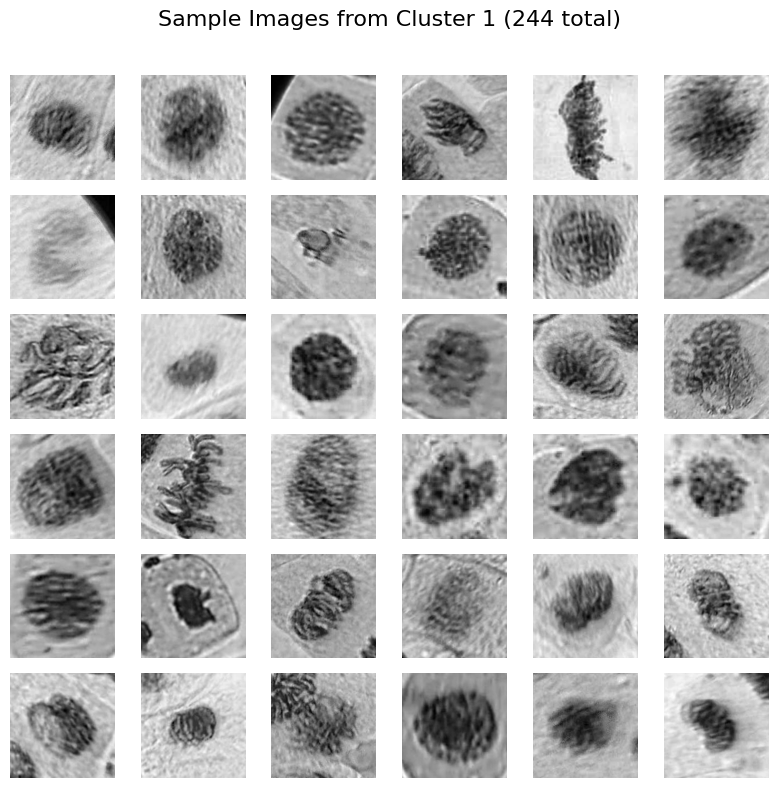

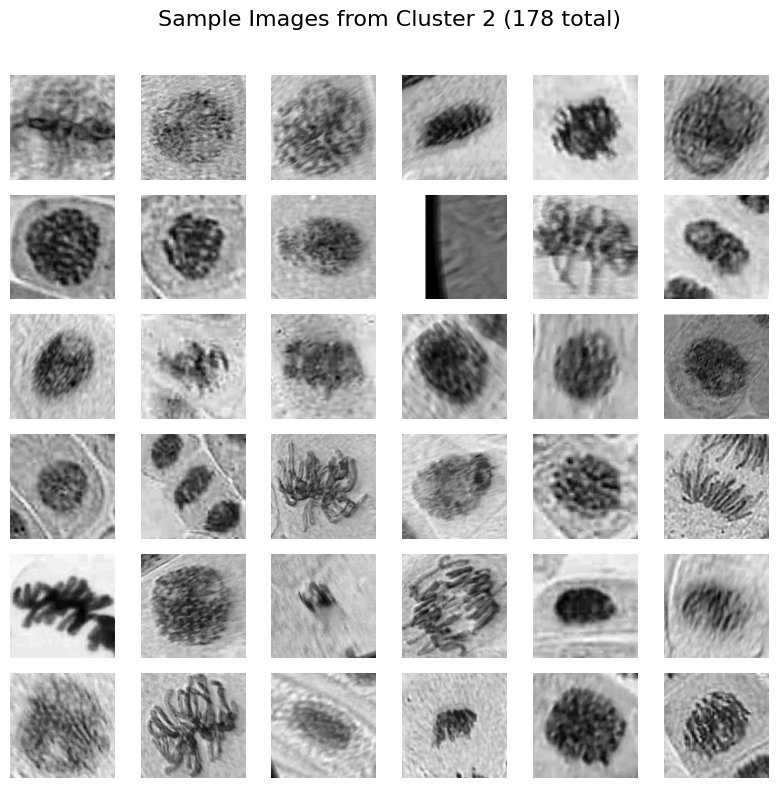

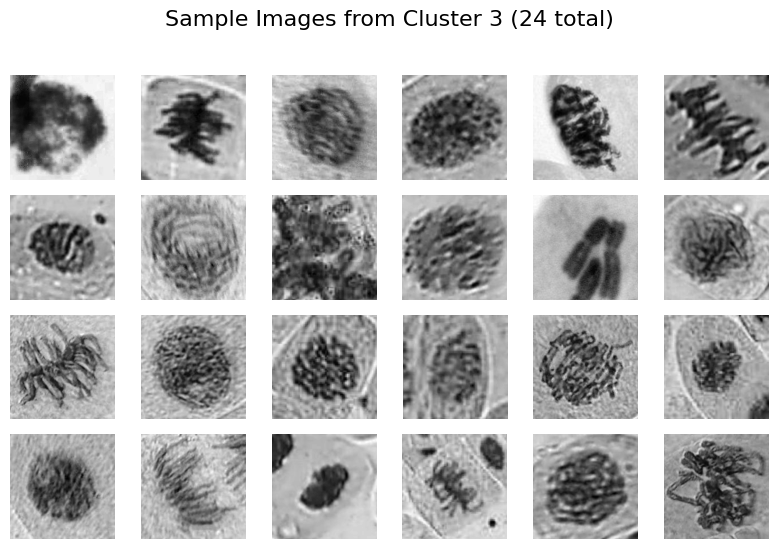

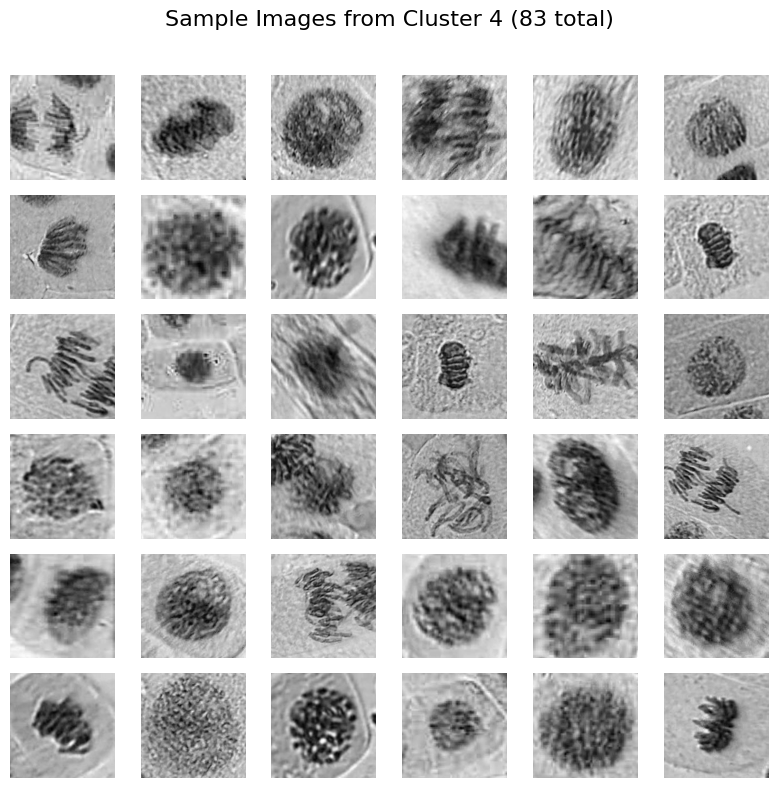

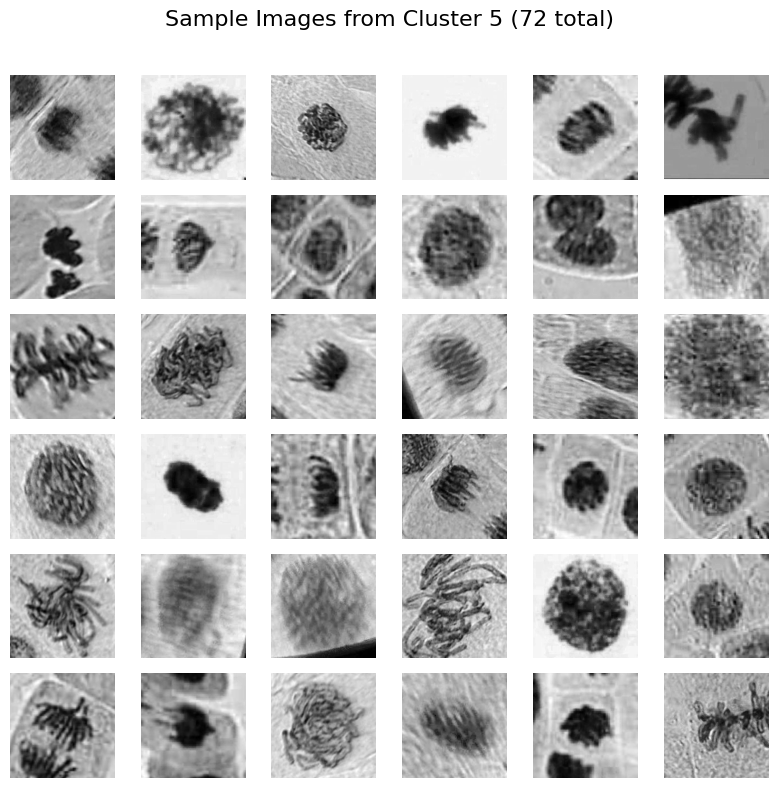

In [15]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import defaultdict

# --- Assuming 'model' and 'test_dataset' are already defined ---

# 1. Get predictions and original images for the entire dataset
print("Processing dataset to get cluster assignments...")
all_predictions = []
all_images = []

# This function was defined in a previous answer
@tf.function
def get_cluster_predictions(model, data):
    x_encoded = model.encoder(data)
    pi_logits = model.fc_pi(x_encoded)
    return tf.argmax(pi_logits, axis=1)

# Loop through the test set to collect images and their predictions
for batch_x in test_dataset:
    preds = get_cluster_predictions(model, batch_x)
    all_predictions.extend(preds.numpy())
    all_images.extend(batch_x.numpy())

# 2. Group images by their predicted cluster
print("Grouping images by cluster...")
images_by_cluster = defaultdict(list)
for img, pred in zip(all_images, all_predictions):
    images_by_cluster[pred].append(img)

# 3. Plot a grid of images for each cluster
print("Plotting grids for each cluster...")
n_centroids = model.n_centroids
n_examples = 36 # We will show a 4x4 grid

for cluster_id in range(n_centroids):
    images = images_by_cluster.get(cluster_id, [])
    
    if not images:
        print(f"\nCluster {cluster_id} has no images assigned to it.")
        continue

    # Create a title for the plot
    plt.figure(figsize=(8, 8))
    plt.suptitle(f"Sample Images from Cluster {cluster_id} ({len(images)} total)", fontsize=16)

    # Get up to 16 images from the cluster
    sample_images = images[:n_examples]
    
    # Create the grid
    for i, image in enumerate(sample_images):
        ax = plt.subplot(6, 6, i + 1)
        ax.imshow(image.squeeze(), cmap='gray')
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()